In [1]:
# ============================================================
# PART 4 — Evaluation & Interpretation
# All imports needed for this part
# ============================================================
import sys
import os

# Must come before any src.* import so Python can locate the package
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, fetch_20newsgroups
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc

from src.ridge_regression import RidgeRegression
from src.lasso_regression import LassoRegression
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
from src.text_features import BagOfWords, TfidfTransformer

np.random.seed(42)

lambdas shape: (50,)
ridge_coef_paths shape: (50, 8)
lasso_coef_paths shape: (50, 8)


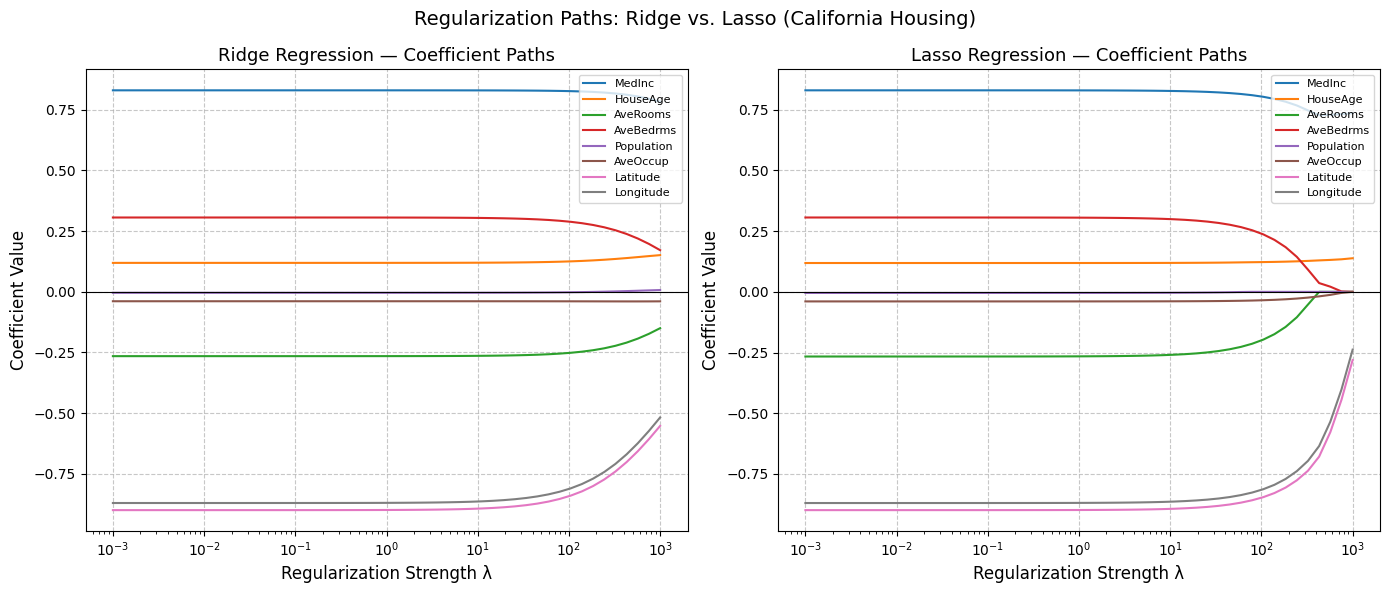

In [2]:
# ============================================================
# PART 4.4.1 — Regularization paths on California Housing
# ============================================================

# --- Load & standardize full California Housing (all 8 features) ---
california = fetch_california_housing(as_frame=True)
X_ca = california.data.values
y_ca = california.target.values
feature_names = california.feature_names

scaler_ca = StandardScaler()
X_ca_scaled = scaler_ca.fit_transform(X_ca)

# --- 50 lambda values log-spaced from 1e-3 to 1e3 ---
lambdas = np.logspace(-3, 3, 50)

# --- Collect coefficient paths ---
ridge_coef_paths = []
lasso_coef_paths = []

for lam in lambdas:
    # Ridge: closed-form, weights include intercept as last element
    ridge = RidgeRegression(lambda_=lam)
    ridge.fit(X_ca_scaled, y_ca)
    # Ridge stores the intercept as the last weight, so keep only feature coefficients
    ridge_coef_paths.append(ridge.weights[:-1])

    # Lasso: coordinate descent
    lasso = LassoRegression(lambda_=lam)
    lasso.fit(X_ca_scaled, y_ca)
    lasso_coef_paths.append(lasso.weights.copy())

ridge_coef_paths = np.array(ridge_coef_paths)   # (50, 8)
lasso_coef_paths = np.array(lasso_coef_paths)   # (50, 8)

print(f"lambdas shape: {lambdas.shape}")
print(f"ridge_coef_paths shape: {ridge_coef_paths.shape}")
print(f"lasso_coef_paths shape: {lasso_coef_paths.shape}")

# --- Plot: two panels side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Set log scale BEFORE plotting so x-axis ticks are computed correctly
ax1.set_xscale('log')
ax2.set_xscale('log')

for j, name in enumerate(feature_names):
    ax1.plot(lambdas, ridge_coef_paths[:, j], label=name)
    ax2.plot(lambdas, lasso_coef_paths[:, j], label=name)

ax1.set_xlabel('Regularization Strength λ', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('Ridge Regression — Coefficient Paths', fontsize=13)
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.8)

ax2.set_xlabel('Regularization Strength λ', fontsize=12)
ax2.set_ylabel('Coefficient Value', fontsize=12)
ax2.set_title('Lasso Regression — Coefficient Paths', fontsize=13)
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8)

plt.suptitle('Regularization Paths: Ridge vs. Lasso (California Housing)', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/Regularization_Paths_Ridge_vs_Lasso.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


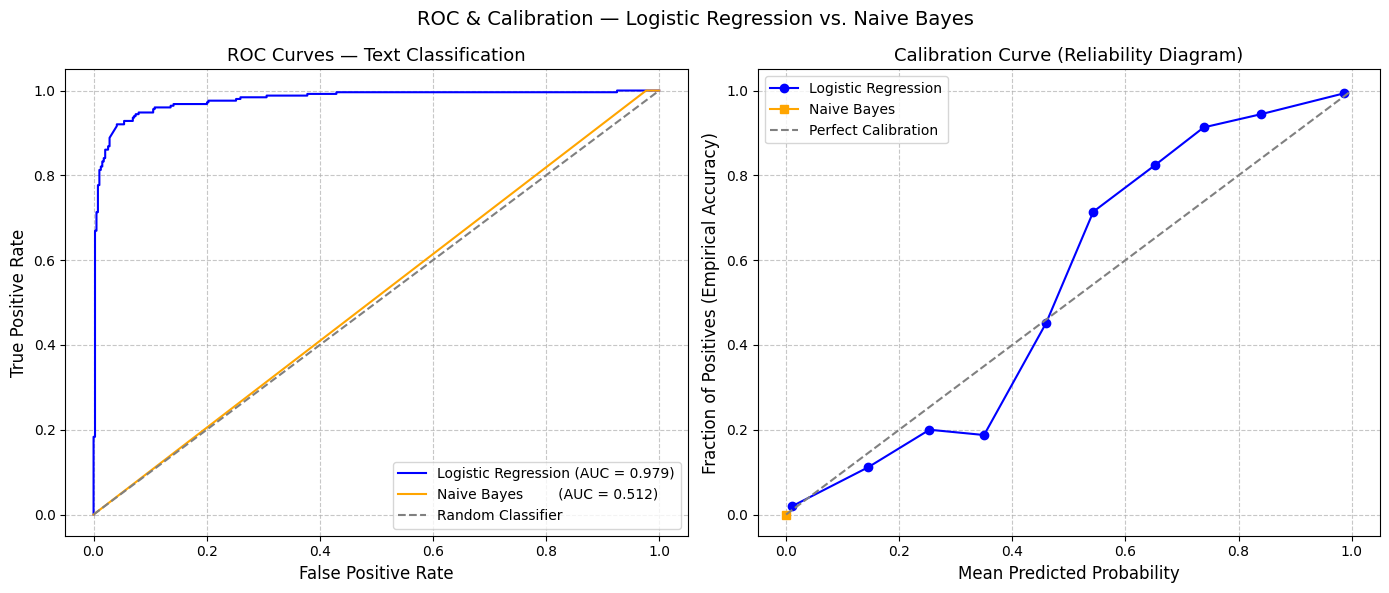

Logistic Regression AUC: 0.9789
Naive Bayes AUC:         0.5116


In [ ]:
# ============================================================
# PART 4.4.2 — ROC curves & calibration (text classification)
# Reuses the trained models from Part 3.4
# ============================================================

# --- Reload 20 Newsgroups binary subset (same as Part 3.4) ---
categories = ['comp.graphics', 'talk.religion.misc']

train_data = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                remove=('headers', 'footers', 'quotes'))

y_train_text = np.array(train_data.target)
y_test_text = np.array(test_data.target)

# --- Build features with BoW + TF-IDF (same pipeline as Part 3.4) ---
bow = BagOfWords()
bow.fit(train_data.data)

X_train_counts = bow.transform(train_data.data)
X_test_counts  = bow.transform(test_data.data)

tfidf = TfidfTransformer()
tfidf.fit(X_train_counts)

X_train_tfidf = tfidf.transform(X_train_counts)
X_test_tfidf  = tfidf.transform(X_test_counts)

# --- Retrain Logistic Regression & Naive Bayes on text features ---
lr_text = LogisticRegression(lr=0.1, lambda_=0.01, max_iter=1000)
lr_text.fit(X_train_tfidf, y_train_text)

nb_text = GaussianNaiveBayes()
nb_text.fit(X_train_tfidf, y_train_text)

# --- Get predicted probabilities for class 1 ---
lr_probs = lr_text.predict_proba(X_test_tfidf)
nb_probs = nb_text.predict_proba(X_test_tfidf)[:, 1]

# --- ROC curves ---
lr_fpr, lr_tpr, _ = roc_curve(y_test_text, lr_probs)
nb_fpr, nb_tpr, _ = roc_curve(y_test_text, nb_probs)
lr_auc = auc(lr_fpr, lr_tpr)
nb_auc = auc(nb_fpr, nb_tpr)

fig, (ax_roc, ax_cal) = plt.subplots(1, 2, figsize=(14, 6))

# ROC panel
ax_roc.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', color='blue')
ax_roc.plot(nb_fpr, nb_tpr, label=f'Naive Bayes        (AUC = {nb_auc:.3f})', color='orange')
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC Curves — Text Classification', fontsize=13)
ax_roc.legend(fontsize=10)
ax_roc.grid(True, linestyle='--', alpha=0.7)

# --- Calibration curves (reliability diagram) ---
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)

def calibration_curve_manual(y_true, y_prob, bin_edges):
    # Bin predictions and compute mean predicted prob and actual accuracy per bin
    mean_pred  = []
    frac_pos   = []
    for i in range(len(bin_edges) - 1):
        mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])
        if mask.sum() > 0:
            mean_pred.append(y_prob[mask].mean())
            frac_pos.append(y_true[mask].mean())
    return np.array(mean_pred), np.array(frac_pos)

lr_mean_pred, lr_frac_pos = calibration_curve_manual(y_test_text, lr_probs, bin_edges)
nb_mean_pred, nb_frac_pos = calibration_curve_manual(y_test_text, nb_probs, bin_edges)

ax_cal.plot(lr_mean_pred, lr_frac_pos, marker='o', label='Logistic Regression', color='blue')
ax_cal.plot(nb_mean_pred, nb_frac_pos, marker='s', label='Naive Bayes',         color='orange')
ax_cal.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
ax_cal.set_xlabel('Mean Predicted Probability', fontsize=12)
ax_cal.set_ylabel('Fraction of Positives (Empirical Accuracy)', fontsize=12)
ax_cal.set_title('Calibration Curve (Reliability Diagram)', fontsize=13)
ax_cal.legend(fontsize=10)
ax_cal.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('ROC & Calibration — Logistic Regression vs. Naive Bayes', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/ROC_and_Calibration_LR_vs_NB.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Naive Bayes AUC:         {nb_auc:.4f}")